In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd 

In [3]:
r = lambda x, y: np.sqrt(x**2 + y**2)

# indice de refraccion de aproximacion eikonal
n = lambda x, y, rmax: 1/ (1 - rmax/ r(x, y))

# Falctor de correccion
corr = lambda x, y, rmax: np.abs(1 - 9/8 * (rmax/ r(x, y))**2)


Las ecuaciones que describen la trayectoria $(x, y)$ y la velocidad $(v_x, v_y)$ de un rayo en esta aproximación viene dada por: 

$$
\frac{dx}{dt} = \frac{v_x}{n(x, y)} \quad \wedge \quad \frac{dy}{dt} = \frac{v_y}{n(x,y)}
$$

y:

$$
\frac{d\, v_x}{dt} = \frac{\partial }{\partial x} n(x, y) \quad \wedge \quad \frac{d\,v_y}{dt} = \frac{\partial}{\partial y} n(x, y)
$$

In [4]:
# definimos las ecuaciones diferenciales de la trayectoria de la luz

def refindex(x, y, A=10):
    eps = 1e-5

    r = np.sqrt(x**2 + y**2)

    n = 1 / (1 - A / (r + eps))

    fac = np.abs(1 - 9 * (A / r)**2 / 8)

    nx = -fac * n**2 * A * x / (r + eps)**3
    ny = -fac * n**2 * A * y / (r + eps)**3

    return n, nx, ny


def flow_deriv(t, state):
    x, y, vx, vy = state

    n, nx, ny = refindex(x, y)

    deriv = np.zeros(4)

    deriv[0] = vx / n
    deriv[1] = vy / n
    deriv[2] = nx
    deriv[3] = ny

    return deriv


## **integración de rayos en el plano $x-y$**

In [5]:
N = 1000 # numero de posiciones iniciales a generar
R = 70 # radio sugerido

# Generamos posiciones iniciales aleatorias dentro de un círculo de radio R
theta = np.random.uniform(0, 2*np.pi, N)
rs = R * np.sqrt(np.random.uniform(0, 1, N))

# posiciones cartesianas en el plano y-z
y = rs * np.cos(theta)
z = rs * np.sin(theta)
x = np.zeros(N)  # eje x

# lo convertimos a coordenadas cilindricas
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arctan2(y, x)


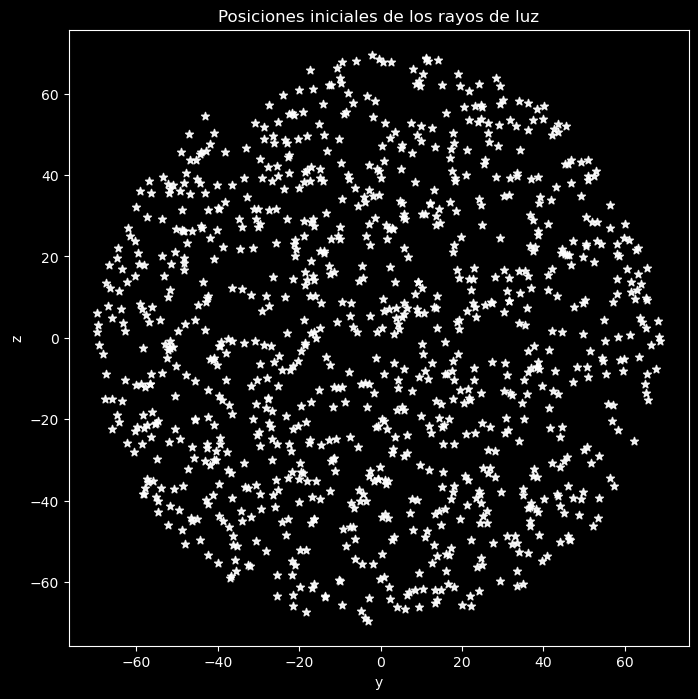

In [6]:
# visualizacion de los puntos en el plano

plt.figure(figsize=(8, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.scatter(y, z, s=35, c='white', marker='*', alpha=0.9)
plt.title('Posiciones iniciales de los rayos de luz', color='white')
plt.xlabel('y', color='white')
plt.ylabel('z', color='white')
plt.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
plt.axis('equal')
plt.show()

## **Integración de rayos en plano $x-y$**

In [7]:
# inicializamos el proceso de integración para la aproximacion eikonal
x0, y0 = -100*np.ones(N), rs

tspan = [0, 400]

# array detiempo con paso 1
ts = np.arange(0, 400, 1)

Resolvemos la ecuacion para todos los rayos


In [9]:
xs = []
ys = []

def event_horizon(t, state):
    x, y, vx, vy = state
    r = np.sqrt(x**2 + y**2)

    return r - 10  # radio del horizonte de eventos

event_horizon.terminal = True
event_horizon.direction = -1

for i in range(N):
    sol = solve_ivp(
        lambda t, state: flow_deriv(t, state),
        tspan,
        np.array([-100.0, rs[i], 1.0, 0.0]),
        t_eval=ts,
        events=event_horizon
    )

    xs.append(sol.y[0])
    ys.append(sol.y[1])




In [ ]:
len(sol.y[0]), len(sol.y[1])

(104, 104)

(-100.0, 100.0)

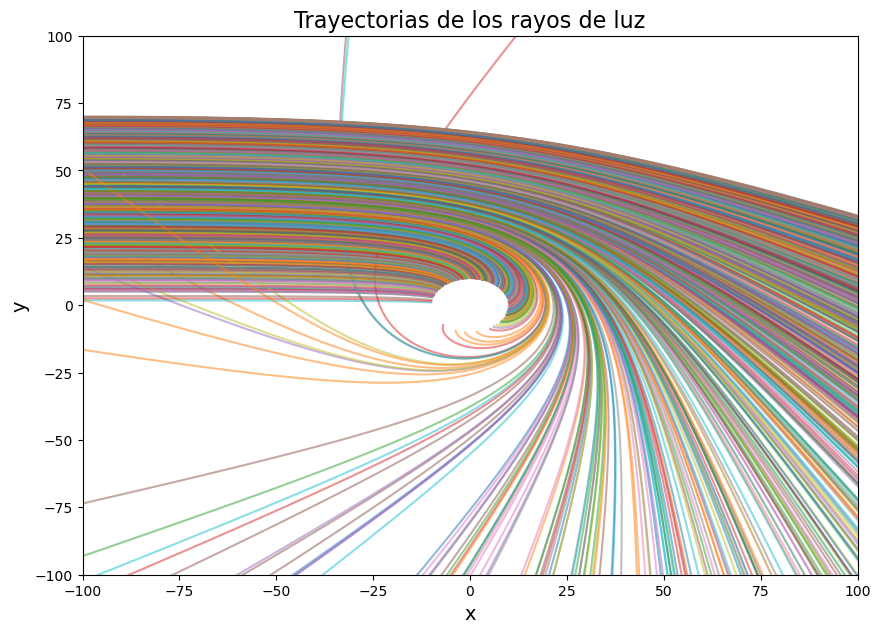

In [ ]:
plt.figure(figsize=(10, 7))

for i in range(N):
    plt.plot(xs[i], ys[i], alpha=0.5)

plt.title('Trayectorias de los rayos de luz', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.savefig('trayectorias.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
xs


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 400))